# cutout

> Cutout specific region out of a stacked image.

In [ ]:
# | default_exp euclid.cutout

In [ ]:
# | exporti

from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.units import Quantity
from astropy.visualization import PercentileInterval, AsinhStretch, ImageNormalize
from astropy.visualization.wcsaxes import SphericalCircle
from astropy.wcs import WCS
from matplotlib.patches import Polygon

from nicl.utilities import maybe_to_value
from nicl.euclid.data_access import DataAccess
from nicl.euclid.utilities import get_nisp_tile, get_nisp_stack

In [ ]:
# | hide

from astropy.nddata import CCDData

from nicl.utilities import physical_to_angular
from nicl.euclid.utilities import default_data_path

In [ ]:
# | export


def get_cutout_and_save(
    image_path,  # full directory of the input FITS file containing the image data
    cutout_size,  # side length of the cutout (either as in degrees or as an angular Quantity)
    output_path,  # directory where the cutout image will be saved
    cutout_name,  # name used to construct the output filename
    ext_match=None,  # optional string to match against extensions name, otherwise will cut out all extensions
    ra=None,  # RA of the cutout center (in degrees or as an angular Quantity), centre of the image if not provided
    dec=None,  # Dec of the cutout center (in degrees or as an angular Quantity), centre of the image if not provided
):  # filename of the saved cutout and SkyCoord of the center of the cutout
    """Extract and save a cutout image from a given larger image."""
    with fits.open(image_path, memmap=True) as hdul:
        if len(hdul) == 1:
            ext_list = [0]
        elif ext_match is not None:
            ext_list = [hdu.name for hdu in hdul if ext_match in hdu.name]
        else:
            ext_list = [hdu.name for hdu in hdul]
        output_hdul = fits.HDUList()
        for ext in ext_list:
            hdu = hdul[ext]
            data = hdu.data
            if data is not None:
                header = hdu.header
                wcs = WCS(header)
                if ra is None or dec is None:
                    centre_pixel = (np.array(data.shape) - 1) / 2
                    centre_ra, centre_dec = wcs.pixel_to_world(*centre_pixel)
                    ext_ra = centre_ra if ra is None else ra
                    ext_dec = centre_dec if dec is None else dec
                else:
                    ext_ra = ra
                    ext_dec = dec
                ext_ra, ext_dec, cutout_size = u.Quantity(
                    (ext_ra, ext_dec, cutout_size), u.deg
                )
                position = SkyCoord(ra=ext_ra, dec=ext_dec, frame="icrs")
                cutout = Cutout2D(data, position, cutout_size, wcs=wcs)
                MatchingHDU = type(hdu)
                # Update the FITS header with the cutout WCS
                cutout_header = header.copy()
                cutout_header.update(cutout.wcs.to_header())
                out_hdu = MatchingHDU(data=cutout.data, header=cutout_header)
                output_hdul.append(out_hdu)
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)
    fn = output_path / f"{cutout_name}.fits"
    output_hdul.writeto(fn, overwrite=True)
    return fn, position

In [ ]:
# | export


def cutout(
    ra,  # RA of the cutout center (in degrees or as an angular Quantity), centre of the image if not provided
    dec,  # Dec of the cutout center (in degrees or as an angular Quantity), centre of the image if not provided
    size,  # side length of the cutout (either as in degrees or as an angular Quantity)
    file_type,  # MER or STK
    input_path,  # path to search for the required input image file
    output_path,  # path to folder in which to output cutout image file
    cutout_name,  # name used to construct the output filename
    filter,  # the filter for the cutout
    da=None,  # optional DataAccess object, to avoid recreating one for each cutout
):  # filename of the saved cutout
    if da is None:
        da = DataAccess()
    if file_type == "MER":
        ids = da.find_tiles_for_target(ra, dec, size / 2, fully_contained=True)
    elif file_type == "STK":
        ids = da.find_observations_for_target(ra, dec, size / 2, fully_contained=True)
    else:
        raise ValueError(f"Invalid file_type provided: {file_type}.")
    if len(ids) == 0:
        if file_type == "MER":
            ids = da.find_tiles_for_target(ra, dec, size / 2, fully_contained=False)
        elif file_type == "STK":
            ids = da.find_observations_for_target(
                ra, dec, size / 2, fully_contained=False
            )
    if len(ids) == 0:
        raise FileNotFoundError("No images found for target.")
    if len(ids) > 1:
        raise NotImplementedError(
            "Automatic stacking of multiple pointings not yet implemented."
        )
    else:
        try:
            if file_type == "MER":
                fn = get_nisp_tile(ids, filter=filter, path=input_path)
            elif file_type == "STK":
                fn = get_nisp_stack(ids, filter=filter, path=input_path)
        except FileNotFoundError:
            fn = None
        if fn is None:
            raise NotImplementedError(
                "Automatic stacking of single pointing not yet implemented."
            )
    cutout_name = f"{cutout_name}_{filter}"
    fn, position = get_cutout_and_save(
        fn, size, output_path, cutout_name, ra=ra, dec=dec
    )
    return fn

In [ ]:
# | export


def show_image(
    image_data,  # 2D array of the image data to display
    image_wcs,  # WCS object associated with the image
    intervalpc=95,  # percentile range to display
    ra=None,  # RA of the center (in degrees or as an angular Quantity) for the region to outline
    dec=None,  # Dec of the center (in degreesor as an angular Quantity) for the region to outline
    radius=None,  # radius of circle or half side length of box to be outlined (in degrees or as an angular Quantity)
    outline_shape=None,  # shape of the region to outline ('circle' or 'box')
):
    """Display an image and optionally outlines a region around a given RA, Dec."""
    interval = PercentileInterval(intervalpc)
    norm = ImageNormalize(image_data, interval=interval, stretch=AsinhStretch())

    fig, ax = plt.subplots(subplot_kw={"projection": image_wcs})
    im = ax.imshow(
        image_data, norm=norm, origin="lower", cmap="Greys", interpolation="nearest"
    )

    if ra is not None and dec is not None:
        ra, dec = Quantity((ra, dec), u.deg)
        Centre = SkyCoord(ra=ra, dec=dec, frame="icrs")

        ax.scatter(
            Centre.ra.deg,
            Centre.dec.deg,
            marker="x",
            s=50,
            c="red",
            transform=ax.get_transform("fk5"),
        )

        if outline_shape == "circle" and radius is not None:
            circle = SphericalCircle(
                (Centre.ra, Centre.dec),
                radius,
                edgecolor="cyan",
                facecolor="none",
                transform=ax.get_transform("fk5"),
            )
            ax.add_patch(circle)

        elif outline_shape == "box" and radius is not None:
            radius_deg = maybe_to_value(radius, u.deg)

            # Scaling RA offset by cos(Dec) to ensure equal angular side lengths
            ra_offset = radius_deg / np.cos(np.radians(dec))

            corners = [
                (ra - ra_offset, dec - radius_deg),  # Bottom-left
                (ra - ra_offset, dec + radius_deg),  # Top-left
                (ra + ra_offset, dec + radius_deg),  # Top-right
                (ra + ra_offset, dec - radius_deg),  # Bottom-right
            ]

            poly = Polygon(
                corners,
                closed=True,
                edgecolor="yellow",
                facecolor="none",
                transform=ax.get_transform("fk5"),
            )
            ax.add_patch(poly)

    plt.colorbar(im, ax=ax, orientation="vertical", label="Pixel Intensity")
    plt.xlabel("RA (J2000)")
    plt.ylabel("Dec (J2000)")

## Example

The following is an example of creating a cutout for a cluster. The cluster info would presumably be read from a table.

In [ ]:
cluster_id = "MCXCJ1754.6+6803"
z = 0.07
ra = 268.662 * u.deg
dec = 68.058 * u.deg
cutout_radius_physical = 750 * u.kpc
path = default_data_path("Q1_R1")
cluster_path = default_data_path("Q1_R1_clusters_v0", cluster_id)
cutout_radius_angular = physical_to_angular(cutout_radius_physical, z)
cutout_name = f"{cluster_id}_MER"
fn = cutout(
    ra,
    dec,
    cutout_radius_angular,
    file_type="MER",
    input_path=path,
    output_path=cluster_path,
    cutout_name=cutout_name,
    filter="H",
)

INFO: OK [astroquery.utils.tap.core]


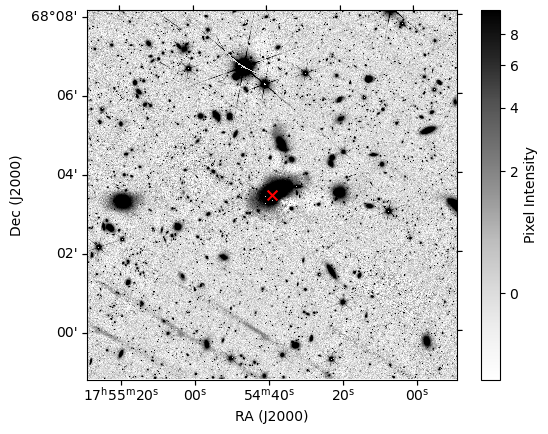

In [ ]:
image = CCDData.read(fn, unit=u.dimensionless_unscaled)
show_image(image.data, image.wcs, ra=ra, dec=dec)

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()

SyntaxError: unterminated string literal (detected at line 17) (<unknown>, line 17)